In [1]:
import pandas as pd


In [2]:
behavior="shopping_behavior_updated.csv"
df=pd.read_csv(behavior)

In [4]:
mymap={'Yes':1,'No':0}
for col in ['Subscription Status', 'Discount Applied']:
    df[col]=df[col].map(mymap).astype('object')


#Several of the following function have auto detect capabilities, so ensure datatypes are accurate:  

In [5]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

In [6]:
df=df.drop(columns='Customer ID')

# ====================================================================  
# utils.BinnerClass.Bin()
# ==================================================================== 

In [7]:
from BinnerClass import Bin
bin=Bin()


In [8]:
#calculate best bin sizes
bin.relational_binner(df,max_cat_to_numeric_p=0.05,min_coeff=0.6,numeric_columns=None,categoric_columns=None)


{'Previous Purchases': 3, 'Review Rating': 4, 'Purchase Amount (USD)': 4}

In [9]:

#access bin object(s)
bin.numeric_target_column_minimums


{'Previous Purchases': 3, 'Review Rating': 4, 'Purchase Amount (USD)': 4}

In [10]:
bin.numeric_feature_col_thresholds


{'Previous Purchases': {'Item Purchased': {'min_w_relationship': 16,
   'max_w_no_relationship': 15,
   'threshold_stat': np.float64(0.04120152402828587)},
  'Gender': {'min_w_relationship': 3,
   'max_w_no_relationship': 2,
   'threshold_stat': np.float64(0.020538089000455926)}},
 'Review Rating': {'Shipping Type': {'min_w_relationship': 7,
   'max_w_no_relationship': 6,
   'threshold_stat': np.float64(0.0472269919419469)},
  'Size': {'min_w_relationship': 16,
   'max_w_no_relationship': 15,
   'threshold_stat': np.float64(0.03464027912801008)},
  'Color': {'min_w_relationship': 4,
   'max_w_no_relationship': 3,
   'threshold_stat': np.float64(0.009603805822731145)}},
 'Purchase Amount (USD)': {'Season': {'min_w_relationship': 4,
   'max_w_no_relationship': 3,
   'threshold_stat': np.float64(0.029445021462080893)}}}

In [11]:
for k, v in bin.numeric_target_column_minimums.items():
    df[f"{k}_binned"]=bin.binner(df[k],v)
    df[f"{k}_binned"]=df[f"{k}_binned"].astype('object')
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Previous Purchases_binned,Review Rating_binned,Purchase Amount (USD)_binned
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,1,Express,1,Yes,14,Venmo,Fortnightly,1,1,2
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,1,Express,1,Yes,2,Cash,Fortnightly,1,1,3
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,1,Free Shipping,1,Yes,23,Credit Card,Weekly,2,1,3
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,1,Next Day Air,1,Yes,49,PayPal,Weekly,3,2,4
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,1,Free Shipping,1,Yes,31,PayPal,Annually,2,1,2


# ====================================================================  
# utils.PearsonCoefficient.PearsonCoefficient  
# ==================================================================== 

In [12]:
from PearsonCoefficient import PearsonCoefficient
pears=PearsonCoefficient()

In [13]:
#allow the function to auto detect numeric columns
pears.test_all_num_num_pearson_coefficient(df,self_detect=True,numeric_columns=None,pseudo_numeric_columns=None,filter_duplicates=False).head(10)

,numeric_1,numeric_2,Correlation
1,Age,Review Rating,-0.021949
2,Age,Previous Purchases,0.040445
3,Age,Purchase Amount (USD),-0.010424
4,Review Rating,Age,-0.021949
6,Review Rating,Previous Purchases,0.004229
7,Review Rating,Purchase Amount (USD),0.030776
8,Previous Purchases,Age,0.040445
9,Previous Purchases,Review Rating,0.004229
11,Previous Purchases,Purchase Amount (USD),0.008063
12,Purchase Amount (USD),Age,-0.010424


In [14]:
#use a wrapper that filters values based on correlation
# return values based on corr= and reject= parameters
pears.num_num_column_pearson_coefficient_relationships(df, corr=0.04,reject=False,self_detect=True,numeric_columns=None,pseudo_numeric_columns=None)
        

,numeric_1,numeric_2,Correlation
1,Previous Purchases,Age,0.040445


# ====================================================================  
# utils.ANOVA.ANOVA
# ====================================================================  

In [15]:
from ANOVA import ANOVA
anova=ANOVA()

In [16]:
# one-way ANOVA
anova.one_way_ANOVA(df[['Color','Review Rating']])

np.float64(0.011262839687853967)

In [17]:
# a non parametric alternative to ANOVA: Kruskal Wallis
anova.one_way_kruskal_wallis(df[['Color','Review Rating']])

np.float64(0.011759042022590125)

In [18]:
# auto detect and test all catigorical to numerical relationships
anova.test_all_cat_num_ANOVA(df,numeric_columns=None,categoric_columns=None).head(10)

,category,numeric,P-value
0,Item Purchased,Age,0.551170
1,Size,Age,0.508993
2,Location,Age,0.459960
3,Payment Method,Age,0.921586
4,Purchase Amount (USD)_binned,Age,0.540410
5,Shipping Type,Age,0.300566
6,Review Rating_binned,Age,0.496000
7,Previous Purchases_binned,Age,0.021196
8,Discount Applied,Age,0.785169
9,Category,Age,0.756186


In [19]:
# a non parametric alternative
anova.test_all_cat_num_kruskal_wallis(df,numeric_columns=None,categoric_columns=None).head(10)

,category,numeric,P-value
0,Item Purchased,Age,0.560833
1,Size,Age,0.512324
2,Location,Age,0.467562
3,Payment Method,Age,0.918715
4,Purchase Amount (USD)_binned,Age,0.543635
5,Shipping Type,Age,0.291690
6,Review Rating_binned,Age,0.491675
7,Previous Purchases_binned,Age,0.021437
8,Discount Applied,Age,0.781163
9,Category,Age,0.763609


In [20]:
# a wrapper that filters results based on p value
anova.cat_num_column_ANOVA_relationships(df, alpha=0.05,keep_similar=False, numeric_columns=None,categoric_columns=None)

,category,numeric,P-value
0,Previous Purchases_binned,Age,0.021196
1,Purchase Amount (USD)_binned,Purchase Amount (USD),0.000000
2,Season,Purchase Amount (USD),0.010576
3,Size,Review Rating,0.043155
4,Purchase Amount (USD)_binned,Review Rating,0.003035
5,Shipping Type,Review Rating,0.038365
6,Review Rating_binned,Review Rating,0.000000
7,Color,Review Rating,0.011263
8,Item Purchased,Previous Purchases,0.042311
9,Previous Purchases_binned,Previous Purchases,0.000000


In [21]:
anova.cat_num_column_kruskal_wallis_relationships(df, alpha=0.05,reject=True, numeric_columns=None,categoric_columns=None)   

,category,numeric,P-value
0,Previous Purchases_binned,Age,0.021437
1,Purchase Amount (USD)_binned,Purchase Amount (USD),0.000000
2,Season,Purchase Amount (USD),0.009854
3,Size,Review Rating,0.043405
4,Purchase Amount (USD)_binned,Review Rating,0.003029
5,Shipping Type,Review Rating,0.038985
6,Review Rating_binned,Review Rating,0.000000
7,Color,Review Rating,0.011759
8,Item Purchased,Previous Purchases,0.043230
9,Previous Purchases_binned,Previous Purchases,0.000000


### use t test to analyze target means based on subcategoories within a given feature column

In [22]:
# perform a two sample welch's t test to compare means from one column based on subcats from another column
anova.two_sample_t_tests(df[['Season','Purchase Amount (USD)']])

,subcat_1,subcat_2,P-value,n_samples_1,n_samples_2
0,Fall,Spring,0.008684,975,999.0
1,Fall,Summer,0.003403,975,955.0
2,Fall,Winter,0.262587,975,971.0
3,Spring,Summer,0.756582,999,955.0
4,Spring,Winter,0.129625,999,971.0
5,Summer,Winter,0.068182,955,971.0


In [23]:
# a wrapper to filter subcategory pairs based on p-values
anova.subcategory_similarities(df[['Season','Purchase Amount (USD)']],alpha=0.05,return_similar=False,min_observations=None)

,subcat_1,subcat_2,P-value,n_samples_1,n_samples_2
0,Fall,Spring,0.008684,975,999.0
1,Fall,Summer,0.003403,975,955.0


In [24]:
df[['Gender','Size']].value_counts()


Gender  Size
Male    M       1165
        L        716
Female  M        590
Male    S        476
Female  L        337
Male    XL       295
Female  S        187
        XL       134
Name: count, dtype: int64

In [51]:
# over/under sample
# force interaciton sizes to be uniform
# takes two catigorical and one numerical values
adjusted=anova.create_uniform_interactions(df[['Gender','Size','Age']],min_size=5, override_min=False, ntile=None)
adjusted.groupby(['Gender','Size'],observed=True,as_index=False)['Age'].agg(['mean','size'])


,Gender,Size,mean,size
0,Female,L,45.283582,134
1,Female,M,44.723881,134
2,Female,S,43.410448,134
3,Female,XL,43.417910,134
4,Male,L,44.462687,134
5,Male,M,46.149254,134
6,Male,S,44.604478,134
7,Male,XL,42.261194,134


In [ ]:
# a two way anova that takes the previous cell's output as input
anova.two_way_ANOVA(adjusted,unbalanced_interaction_sizes=False,verbose=True)

Interacting factors: [('Female', 'L'), ('Female', 'M'), ('Female', 'S'), ('Female', 'XL'), ('Male', 'L'), ('Male', 'M'), ('Male', 'S'), ('Male', 'XL')]
Non interacting: where count < 5 interaction factors: []
SST = SSA+SSB+SSAB+SSE: False
np.isclose(SST, SSA+SSB+SSAB+SSE): True
SST: 239144.35447761195
SSA + SSB + SSAB + SSE: 239144.35447761198
Residual: -2.9103830456733704e-11
If the residual error is large, try another model 
two_way_ANOVA_for_un_balanced_data(), which implements statsmodels.api
or over/under sample the data.


{'Gender': np.float64(0.8605501871816292),
 'Size': np.float64(0.20390318653566064),
 'interaction': np.float64(0.6574425511522224)}

# ====================================================================  
# utils.Chi2.Chi2  
# ====================================================================  

In [27]:
from Chi2 import Chi2
chi=Chi2()

In [28]:
# get makeup of 2 categorical column observations
chi.column_makeup(df,'Gender','Color').head(5)

,Gender,Color,count,pct_makeup
0,Female,Beige,40,0.010256
1,Female,Black,54,0.013846
2,Female,Blue,52,0.013333
3,Female,Brown,46,0.011795
4,Female,Charcoal,50,0.012821


In [29]:
# a contingency table
chi.contingency_table(df,'Gender','Color',kind='joint_probability')

,Beige,Black,Blue,Brown,Charcoal,Cyan,Gold,Gray,Green,Indigo,...,Pink,Purple,Red,Silver,Teal,Turquoise,Violet,White,Yellow,RIGHT_MARGIN
Gender,,,,,,,,,,,,,,,,,,,,,
Female,0.010256,0.013846,0.013333,0.011795,0.012821,0.012051,0.010513,0.01359,0.014359,0.011538,...,0.014872,0.010769,0.011282,0.013333,0.01359,0.010256,0.01359,0.011538,0.015385,0.32
Male,0.027436,0.028974,0.025641,0.024359,0.02641,0.030513,0.024872,0.027179,0.028974,0.026154,...,0.024359,0.027949,0.026667,0.031026,0.030513,0.026923,0.028974,0.024872,0.029231,0.68
BOTTOM_MARGIN,0.037692,0.042821,0.038974,0.036154,0.039231,0.042564,0.035385,0.040769,0.043333,0.037692,...,0.039231,0.038718,0.037949,0.044359,0.044103,0.037179,0.042564,0.03641,0.044615,1.0


In [30]:
#frequency table
chi.frequencies_table(df,'Gender','Color',kind='frequency')

Color,Beige,Black,Blue,Brown,Charcoal,Cyan,Gold,Gray,Green,Indigo,...,Peach,Pink,Purple,Red,Silver,Teal,Turquoise,Violet,White,Yellow
Gender,,,,,,,,,,,,,,,,,,,,,
Female,40,54,52,46,50,47,41,53,56,45,...,48,58,42,44,52,53,40,53,45,60
Male,107,113,100,95,103,119,97,106,113,102,...,101,95,109,104,121,119,105,113,97,114


In [31]:
# test two columns for independence
chi.chi_squared_independence(df,'Gender','Color')

np.float64(0.9717119112341447)

In [32]:
# let auto detect test every categorical combination
chi.test_all_cat_columns_chi_independence(df,columns=None,additional=True).head()

,category_a,category_b,P-value
0,Item Purchased,Size,0.807368
1,Item Purchased,Location,0.999975
2,Item Purchased,Payment Method,0.737619
3,Item Purchased,Purchase Amount (USD)_binned,0.452949
4,Item Purchased,Shipping Type,0.499326


In [33]:
# a wrapper to filter based on p values
chi.categorical_column_relationships(df, alpha=0.05, columns=None, additional=True).head()

,category_a,category_b,P-value
0,Item Purchased,Previous Purchases_binned,0.024053
1,Item Purchased,Category,0.000000
2,Shipping Type,Gender,0.031607
3,Review Rating_binned,Color,0.028231
4,Previous Purchases_binned,Frequency of Purchases,0.028537


In [34]:
# analyze subcategory pairs. This looks in both directions: col1->col2 & col2->col1
chi.chi_subcat_analysis(df[['Shipping Type','Gender']]).head()


,subcat_a,subcat_b,source_column,P-value
0,Express,Next Day Air,Shipping Type,0.826957
1,Express,Standard,Shipping Type,0.323863
2,Express,Store Pickup,Shipping Type,0.942098
3,Express,Free Shipping,Shipping Type,0.008312
4,Express,2-Day Shipping,Shipping Type,0.251948


In [35]:
# a wrapper to filter the subcat analysis based on p-value
chi.subcategory_similarities(df[['Shipping Type','Gender']],alpha=0.05,return_similar=False,drop_nans=True)

,subcat_a,subcat_b,source_column,P-value
0,Express,Free Shipping,Shipping Type,0.008312
1,Next Day Air,Free Shipping,Shipping Type,0.004221
2,Store Pickup,Free Shipping,Shipping Type,0.006596
3,Male,Female,Gender,0.031607


In [36]:
#perfom a goodness of fit test <default is to test against a uniform distribution>
chi.chi_squared_goodness_of_fit(df['Shipping Type'],expected_probs=None)

np.float64(0.872030582770527)

In [37]:
# use auto detect to detect all columns goodness-of-fit to a uniform distribution
chi.test_all_cat_columns_chi_good_of_fit(df,columns=None,additional=True).head()

,category,P-value
0,Item Purchased,7.283611e-01
1,Size,3.021391e-224
2,Location,7.567125e-01
3,Payment Method,3.766844e-01
4,Purchase Amount (USD)_binned,2.172373e-01


In [38]:
# a wrapper to filter results based on parameters alpha=0.5 and is_uniform=False
chi.categorical_column_good_fit(df,alpha=0.5,is_uniform=False)

,category,P-value
0,Size,3.021391e-224
1,Payment Method,3.766844e-01
2,Purchase Amount (USD)_binned,2.172373e-01
3,Review Rating_binned,4.392695e-01
4,Discount Applied,2.270063e-18
5,Category,4.153661e-270
6,Subscription Status,1.756047e-181
7,Promo Code Used,2.270063e-18
8,Gender,6.228002e-112


the following Chi2 functions deal with determining if one column is simply subcategories partitioned by another column  
auto_detect is not yet supported for these

In [39]:

cols=['Gender','Item Purchased', 'Category','Location', 'Size', 'Color', 'Season', 'Size', 'Color', 'Season']

In [40]:
# a deterministic approach
chi.get_deterministic_super_subcat_pairs(df,cols,min_proportion=1.0)

,supercategory,subcategory,proportion_are_true_subcategories
0,Category,Item Purchased,1.0


In [41]:
chi.imperfect_super_subcat_pairs(df,cols,max_evidence=.895)

,supercategory,subcategory,ShannonEntropyBits
0,Category,Item Purchased,-1.442823e-12
1,Gender,Size,8.949111e-01


In [42]:
df.groupby(['Gender','Size'],observed=True).size()

Gender  Size
Female  L        337
        M        590
        S        187
        XL       134
Male    L        716
        M       1165
        S        476
        XL       295
dtype: int64

# ====================================================================  
# utils.PoissonSalesForecasting.PoissonSalesForecasting  
# ====================================================================  

In [43]:
from PoissonSalesForecasting import PoissonSalesForecasting
model=PoissonSalesForecasting()


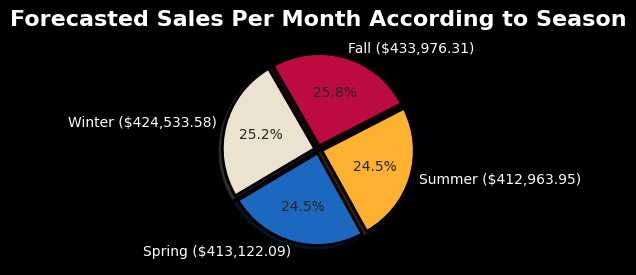

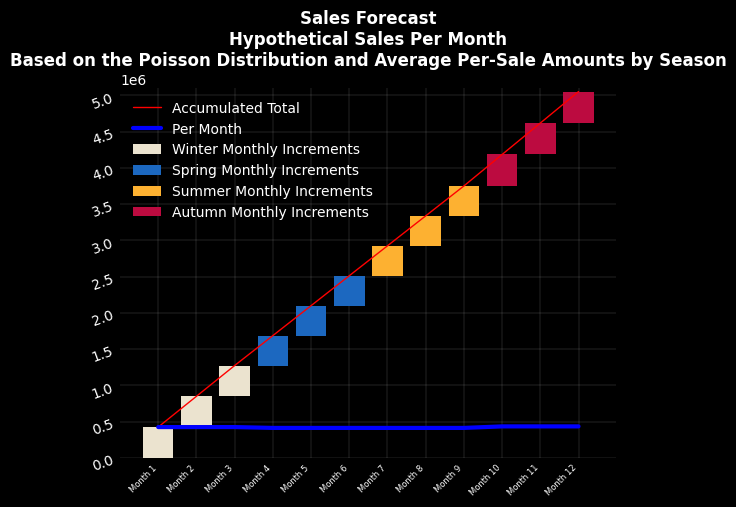

In [44]:
model.plot_mean_seasonal_sales(df,'month') 

model.floating_bar_plot(df,'month')

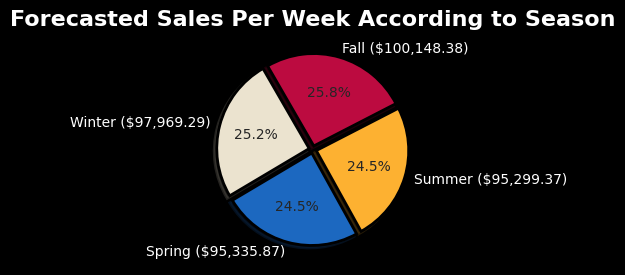

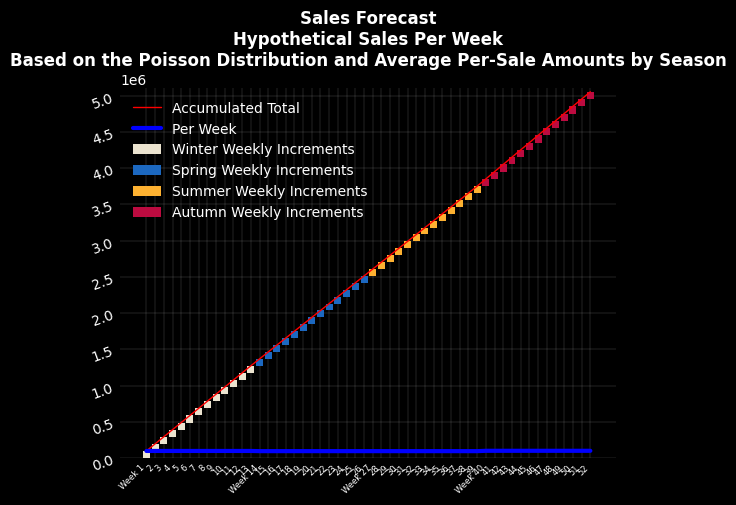

In [45]:
model.plot_mean_seasonal_sales(df,'week') 
model.floating_bar_plot(df,'week')

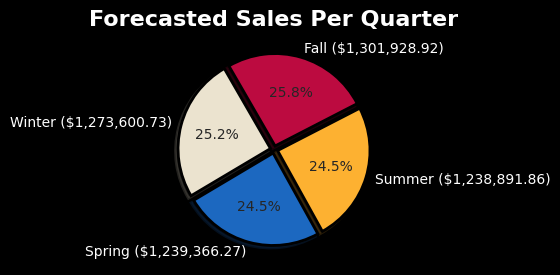

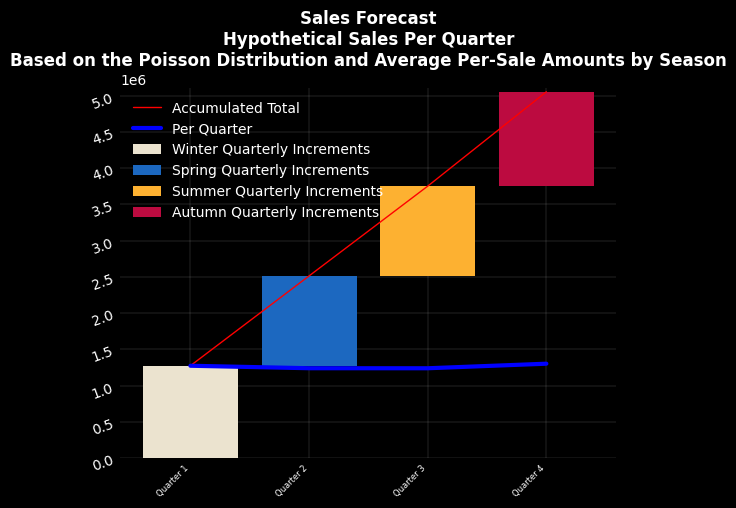

In [46]:
model.plot_mean_seasonal_sales(df,'quarter') 
model.floating_bar_plot(df,'season')

# ====================================================================  
# utils.MuEstimator.MuEstimator
# ==================================================================== 

,Item Purchased,Category,proportion,num_observations,successes,lower,upper
0,Coat,Outerwear,0.496914,324,161,0.451224,0.542603
1,Jacket,Outerwear,0.503086,324,163,0.457397,0.548776
2,Boots,Footwear,0.240401,599,144,0.211681,0.269120
3,Sneakers,Footwear,0.242070,599,145,0.213283,0.270857
4,Shoes,Footwear,0.250417,599,150,0.221300,0.279535


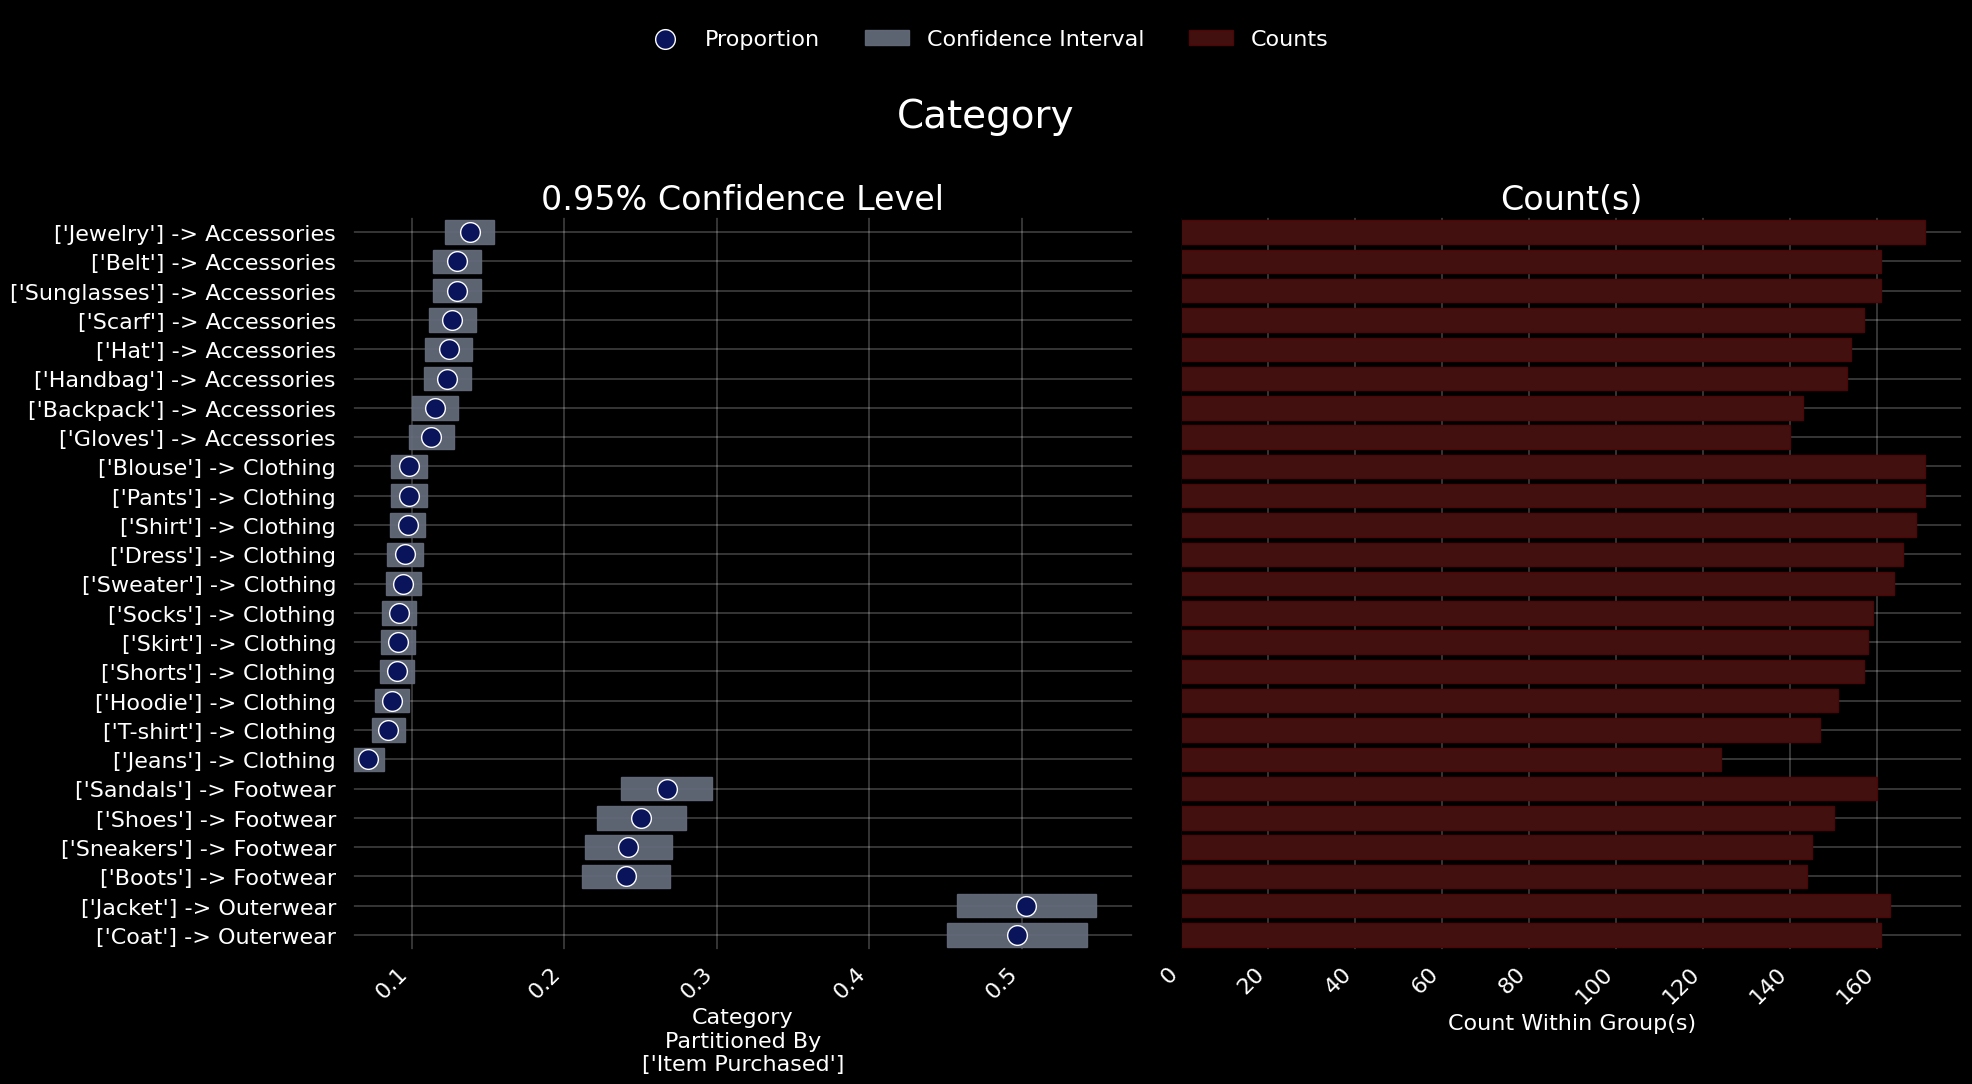

In [47]:
from MuEstimator import MuEstimator

muest=MuEstimator()

target_col, confidence_level, partition_by = 'Category',.95,['Item Purchased']

disp_df = muest.get_proportion_estimate_df(df,target_col,confidence_level,partition_by)
display(disp_df.head())
muest.get_floating_proportion_hbar(df,target_col,confidence_level,partition_by,plot_title=None)



,Gender,Size,min,mean,median,max,std,size,lower,upper
0,Female,XL,2.5,3.850746,4.0,5.0,0.759773,134,3.722105,3.979387
1,Female,S,2.5,3.813904,3.8,5.0,0.722837,187,3.710302,3.917506
2,Male,XL,2.5,3.782034,3.8,5.0,0.715558,295,3.700379,3.863689
3,Female,L,2.5,3.746291,3.8,5.0,0.731961,337,3.668142,3.824439
4,Male,S,2.5,3.785084,3.8,5.0,0.711772,476,3.721142,3.849026
5,Female,M,2.5,3.690847,3.6,5.0,0.701067,590,3.634278,3.747417
6,Male,L,2.5,3.755726,3.7,5.0,0.711844,716,3.703586,3.807867
7,Male,M,2.5,3.733047,3.7,5.0,0.716579,1165,3.691899,3.774195


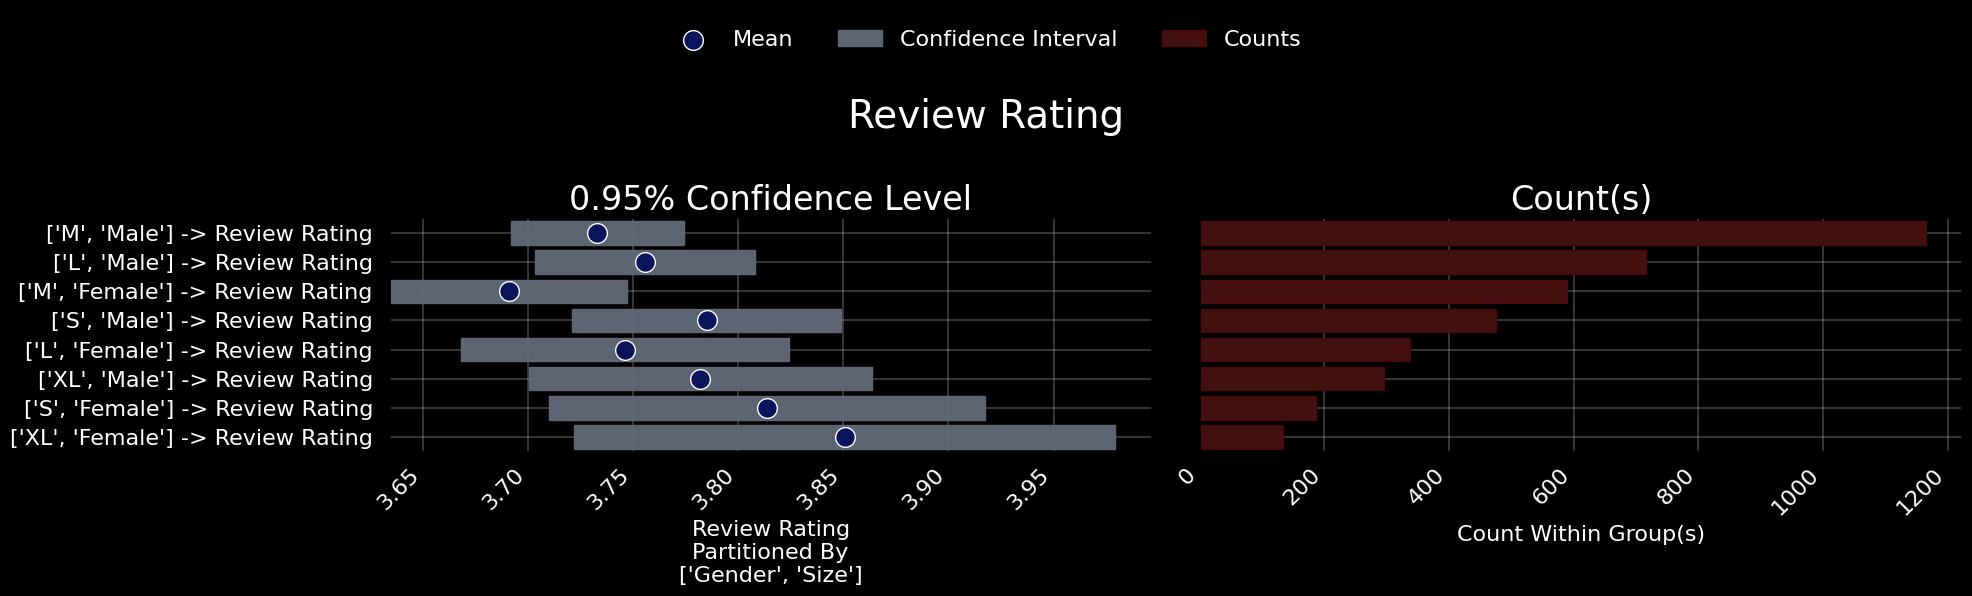

In [48]:

target_col2,confidence_level2,partition_by2 = 'Review Rating',0.95,['Gender','Size']

disp_df2 = muest.get_mean_estimate_df(df,target_col2,confidence_level2,partition_by2)
display(disp_df2)
muest.get_floating_mean_hbar(df,target_col2,confidence_level2,partition_by2,plot_title=None,median=False)